# Student & Teacher Performance Analytics

A simple, step-by-step notebook version — same result as `analytics.py`, but written
as plain top-to-bottom cells instead of a class, so it's easier to read and tweak.

**Flow:** connect to MySQL → load tables → clean → compute the numbers that matter →
one matplotlib dashboard.

Before running: copy `.env.example` to `.env` in this folder and fill in your real
DB credentials (same as the script version).

In [11]:
# --- Imports ---
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus

warnings.filterwarnings("ignore")
load_dotenv()  # reads DB_HOST, DB_USER, DB_PASSWORD, DB_NAME from your .env file

plt.style.use("seaborn-v0_8-darkgrid")

## 1. Connect to MySQL

Credentials come from `.env` — nothing is hardcoded here, so it's safe to share this
notebook without leaking your password.

In [12]:
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER", "root")
DB_PASSWORD = os.getenv("DB_PASSWORD", "tejjadhav@1234")
DB_NAME = os.getenv("DB_NAME", "clg_register")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{quote_plus(DB_PASSWORD)}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Quick test — this will raise an error immediately if the credentials/host are wrong
with engine.connect():
    print("Connected to MySQL successfully!")

Connected to MySQL successfully!


## 2. Load the tables

Each MySQL table becomes one pandas DataFrame.

In [13]:
students_df    = pd.read_sql("SELECT * FROM students", engine)
departments_df = pd.read_sql("SELECT * FROM departments", engine)
subjects_df    = pd.read_sql("SELECT * FROM subjects", engine)
teachers_df    = pd.read_sql("SELECT * FROM teachers", engine)
marks_df       = pd.read_sql("SELECT * FROM marks", engine)
attendance_df  = pd.read_sql("SELECT * FROM attendance", engine)
feedback_df    = pd.read_sql("SELECT * FROM feedback", engine)

print("Rows loaded:")
for name, df in [("students", students_df), ("departments", departments_df),
                  ("subjects", subjects_df), ("teachers", teachers_df),
                  ("marks", marks_df), ("attendance", attendance_df),
                  ("feedback", feedback_df)]:
    print(f"  {name:<12} {len(df)} rows")

Rows loaded:
  students     2392 rows
  departments  5 rows
  subjects     25 rows
  teachers     50 rows
  marks        11960 rows
  attendance   71760 rows
  feedback     11960 rows


## 3. Clean the data

- Convert marks/ratings to numbers (in case anything imported as text)
- If `marks.total_marks` exists, convert marks to a 0–100 percentage; otherwise assume
  `marks_obtained` is already a percentage
- Standardize attendance status text (`present ` → `Present`)
- Drop duplicate rows and rows with missing key values

In [14]:
# Marks
marks_df["marks_obtained"] = pd.to_numeric(marks_df["marks_obtained"], errors="coerce")
if "total_marks" in marks_df.columns:
    marks_df["total_marks"] = pd.to_numeric(marks_df["total_marks"], errors="coerce")
    marks_df["marks_pct"] = marks_df["marks_obtained"] / marks_df["total_marks"] * 100
else:
    marks_df["marks_pct"] = marks_df["marks_obtained"]

marks_df = marks_df.dropna(subset=["marks_obtained"]).drop_duplicates()

# Attendance
attendance_df["status"] = attendance_df["status"].astype(str).str.strip().str.capitalize()
attendance_df = attendance_df[attendance_df["status"].isin(["Present", "Absent"])]
attendance_df = attendance_df.drop_duplicates()

# Feedback
feedback_df["rating"] = pd.to_numeric(feedback_df["rating"], errors="coerce")
feedback_df = feedback_df.dropna(subset=["rating"]).drop_duplicates()

print("Cleaned. Marks:", len(marks_df), "| Attendance:", len(attendance_df), "| Feedback:", len(feedback_df))

Cleaned. Marks: 11960 | Attendance: 71760 | Feedback: 11960


## 4. Compute the numbers that matter

Instead of dumping every table, we build one clean summary table — **one row per
student** — with their average marks, attendance %, and whether they need attention.

A student is flagged **at risk** if either:
- average marks < 40%, or
- attendance < 75%

In [15]:
PASS_MARK = 40
LOW_ATTENDANCE = 75

# Average marks per student
avg_marks = marks_df.groupby("student_id")["marks_pct"].mean().rename("avg_marks_pct")

# Attendance % per student
attendance_pct = (
    attendance_df.groupby("student_id")["status"]
    .apply(lambda s: (s == "Present").mean() * 100)
    .rename("attendance_pct")
)

# Build one row per student
summary = students_df[["student_id", "name", "department_id", "year"]].copy()
summary = summary.merge(avg_marks, on="student_id", how="left")
summary = summary.merge(attendance_pct, on="student_id", how="left")
summary = summary.merge(departments_df[["department_id", "department_name"]], on="department_id", how="left")

summary["at_risk"] = (summary["avg_marks_pct"] < PASS_MARK) | (summary["attendance_pct"] < LOW_ATTENDANCE)

summary.sort_values("avg_marks_pct").head(10)

,student_id,name,department_id,year,avg_marks_pct,attendance_pct,department_name,at_risk
2219,3220,Student2220,1,TY,0.74,3.333333,Computer Engineering,True
1512,2513,Student1513,3,FY,0.94,10.000000,Electronics Engineering,True
629,1630,Student630,4,TY,1.00,6.666667,Civil Engineering,True
87,1088,Student88,4,FY,1.12,10.000000,Civil Engineering,True
963,1964,Student964,2,TY,1.38,13.333333,Mechanical Engineering,True
1724,2725,Student1725,3,SY,1.58,10.000000,Electronics Engineering,True
67,1068,Student68,5,FY,1.72,6.666667,Information Technology,True
484,1485,Student485,5,FY,1.92,3.333333,Information Technology,True
1230,2231,Student1231,5,TY,2.00,6.666667,Information Technology,True
2310,3311,Student2311,5,SY,2.06,6.666667,Information Technology,True


## 5. Subject and teacher summaries

In [16]:
# Pass rate and average marks per subject
subject_summary = marks_df.groupby("subject_id").agg(
    avg_marks_pct=("marks_pct", "mean"),
    pass_pct=("marks_pct", lambda s: (s >= PASS_MARK).mean() * 100),
).reset_index()
subject_summary = subject_summary.merge(subjects_df[["subject_id", "subject_name"]], on="subject_id", how="left")

# Average feedback rating per teacher
teacher_summary = feedback_df.groupby("teacher_id")["rating"].mean().reset_index()
teacher_summary.columns = ["teacher_id", "avg_rating"]
teacher_summary = teacher_summary.merge(teachers_df[["teacher_id", "name"]], on="teacher_id", how="left")

print("Subject performance:")
display(subject_summary.sort_values("avg_marks_pct"))
print("\nTeacher feedback:")
display(teacher_summary.sort_values("avg_rating"))

Subject performance:


,subject_id,avg_marks_pct,pass_pct,subject_name
7,8,46.535146,57.740586,Machine Design
8,9,46.648536,57.531381,Manufacturing Processes
20,21,46.678903,56.962025,Web Technologies
21,22,46.707806,57.594937,Cloud Computing
22,23,46.853797,58.227848,Cyber Security
9,10,46.857950,58.995816,Heat Transfer
5,6,47.122803,57.740586,Thermodynamics
23,24,47.131224,57.594937,Data Mining
6,7,47.219247,59.414226,Fluid Mechanics
24,25,47.398312,57.383966,Mobile App Development



Teacher feedback:


,teacher_id,avg_rating,name
12,13,3.522321,Prof. Yadav
41,42,3.556522,Dr. Bhat
37,38,3.573333,Dr. Verma
14,15,3.575893,Prof. Naik
44,45,3.577869,Prof. Reddy
35,36,3.580000,Dr. Chatterjee
46,47,3.598361,Prof. Gupta
11,12,3.598425,Dr. Rao
10,11,3.607143,Prof. Joshi
29,30,3.620087,Dr. Chatterjee


## 6. Plain-English summary for teachers

Everything above condensed into a few lines — this is the part a teacher actually
wants to read.

In [17]:
overall_pass_pct = (marks_df["marks_pct"] >= PASS_MARK).mean() * 100
at_risk_students = summary[summary["at_risk"]].sort_values("avg_marks_pct")
weakest_subject = subject_summary.sort_values("avg_marks_pct").iloc[0]
lowest_teacher = teacher_summary.sort_values("avg_rating").iloc[0]

print("TEACHER ACTION SUMMARY")
print("-" * 40)
print(f"Overall pass rate:        {overall_pass_pct:.1f}%")
print(f"Students at risk:         {len(at_risk_students)}")
print(f"Weakest subject:          {weakest_subject['subject_name']} ({weakest_subject['avg_marks_pct']:.1f}%)")
print(f"Lowest-rated teacher:     {lowest_teacher['name']} ({lowest_teacher['avg_rating']:.2f}/5)")
print()
print("Students to check on first:")
display(at_risk_students[["name", "avg_marks_pct", "attendance_pct"]].head(5))

TEACHER ACTION SUMMARY
----------------------------------------
Overall pass rate:        60.7%
Students at risk:         1766
Weakest subject:          Machine Design (46.5%)
Lowest-rated teacher:     Prof. Yadav (3.52/5)

Students to check on first:


,name,avg_marks_pct,attendance_pct
2219,Student2220,0.74,3.333333
1512,Student1513,0.94,10.000000
629,Student630,1.00,6.666667
87,Student88,1.12,10.000000
963,Student964,1.38,13.333333


## 7. One dashboard, six charts

All the visuals in a single figure using `GridSpec`, so you get the full picture at
a glance instead of scrolling through separate plots.

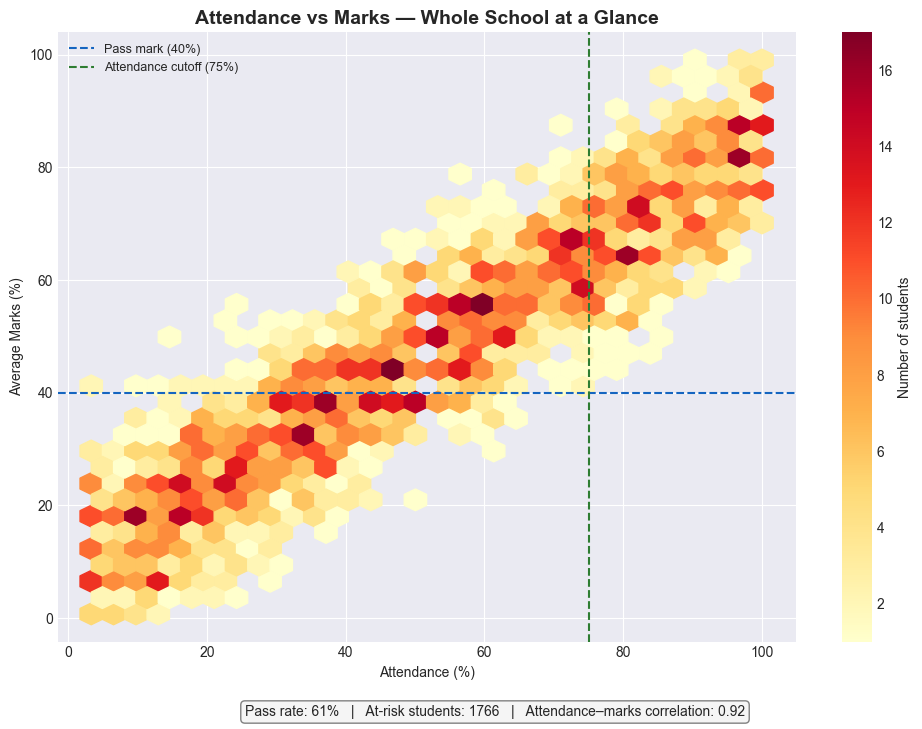


1766 students flagged at risk. Top 15 to check on first:



,Student,Department,Avg Marks %,Attendance %
2219,Student2220,Computer Engineering,0.7,3.3
1512,Student1513,Electronics Engineering,0.9,10.0
629,Student630,Civil Engineering,1.0,6.7
87,Student88,Civil Engineering,1.1,10.0
963,Student964,Mechanical Engineering,1.4,13.3
1724,Student1725,Electronics Engineering,1.6,10.0
67,Student68,Information Technology,1.7,6.7
484,Student485,Information Technology,1.9,3.3
1230,Student1231,Information Technology,2.0,6.7
2310,Student2311,Information Technology,2.1,6.7


In [20]:
PASS_MARK = 40
LOW_ATTENDANCE = 75

plot_df = summary.dropna(subset=["attendance_pct", "avg_marks_pct"]).copy()

# --- Chart: density of the whole school, attendance vs marks ---
fig, ax = plt.subplots(figsize=(10, 7))
hb = ax.hexbin(plot_df["attendance_pct"], plot_df["avg_marks_pct"],
               gridsize=30, cmap="YlOrRd", mincnt=1)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of students")

ax.axhline(PASS_MARK, color="#1565c0", linestyle="--", linewidth=1.5, label=f"Pass mark ({PASS_MARK}%)")
ax.axvline(LOW_ATTENDANCE, color="#2e7d32", linestyle="--", linewidth=1.5, label=f"Attendance cutoff ({LOW_ATTENDANCE}%)")

overall_pass_pct = (marks_df["marks_pct"] >= PASS_MARK).mean() * 100
at_risk_n = plot_df["at_risk"].sum()
corr = plot_df[["attendance_pct", "avg_marks_pct"]].corr().iloc[0, 1]

ax.set_title("Attendance vs Marks — Whole School at a Glance", fontsize=14, fontweight="bold")
ax.set_xlabel("Attendance (%)")
ax.set_ylabel("Average Marks (%)")
ax.legend(loc="upper left", fontsize=9)

stats_txt = (f"Pass rate: {overall_pass_pct:.0f}%   |   "
             f"At-risk students: {at_risk_n}   |   "
             f"Attendance\u2013marks correlation: {corr:.2f}")
fig.text(0.5, -0.03, stats_txt, ha="center", fontsize=10,
          bbox=dict(boxstyle="round", facecolor="#f5f5f5", edgecolor="gray"))

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Table: the actual students who need attention first ---
at_risk_table = (
    plot_df[plot_df["at_risk"]]
    .sort_values("avg_marks_pct")
    [["name", "department_name", "avg_marks_pct", "attendance_pct"]]
    .head(15)
    .rename(columns={"name": "Student", "department_name": "Department",
                      "avg_marks_pct": "Avg Marks %", "attendance_pct": "Attendance %"})
)
at_risk_table["Avg Marks %"] = at_risk_table["Avg Marks %"].round(1)
at_risk_table["Attendance %"] = at_risk_table["Attendance %"].round(1)

print(f"\n{len(plot_df[plot_df['at_risk']])} students flagged at risk. Top 15 to check on first:\n")
display(at_risk_table)